In [1]:
import sys
sys.path.append('../../dataloaders/3W')
sys.path.append('../../../../3W')
import os
os.environ['path3W'] = '../../../'
import numpy as np
import pandas as pd
import torch

In [2]:
from loader import Loader3W
import importlib
importlib.reload(sys.modules['loader'])
import toolkit
importlib.reload(sys.modules['toolkit'])
ld = Loader3W()

In [ ]:
#ld.get_ids_from_wells_with_event_type([8])
#ld.load_stats()
#ld.extract_stats(['ABER-CKP', 'P-ANULAR', 'P-PDG','P-TPT','T-MON-CKP','T-PDG','T-TPT'])
#ld.save_stats()

In [3]:
ld.load_stats()
dg = ld.preprocess()

In [68]:
from tsdiffusion.ts_diffusion3 import TSDiffusion
importlib.reload(sys.modules['tsdiffusion.ts_diffusion3'])
ts_diffusion = TSDiffusion(
    in_channels=17,
    latent_dim=170,
    model_dim=170*2,
    static_dim=7,
    hidden_dim=1024,
    num_steps=1000
    )


In [14]:
import torch
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
ts_diffusion.train3W(
    window_size=15,
    batch_size=1000,
    epochs=5,
)

Starting epoch 1/5 - dataset 1/9 - Partial Validation Loss: inf
Ep 1: L1=92.81 L2=0.95 L3=0.29 L4=0.70
Ep 1: L1=63.80 L2=0.51 L3=0.27 L4=0.72
Ep 1: L1=150.72 L2=0.46 L3=0.24 L4=0.58
Ep 1: L1=148.76 L2=0.37 L3=0.18 L4=0.78
Ep 1: L1=101.33 L2=0.89 L3=0.06 L4=0.64
Starting epoch 1/5 - dataset 2/9 - Partial Validation Loss: 40.956646
Ep 1: L1=199.24 L2=0.92 L3=0.00 L4=0.41
Ep 1: L1=13.19 L2=0.88 L3=0.01 L4=0.18
Ep 1: L1=-7.51 L2=0.37 L3=0.00 L4=0.34
Ep 1: L1=-8.14 L2=0.58 L3=0.01 L4=0.30
Ep 1: L1=3.94 L2=0.85 L3=0.00 L4=0.15
Starting epoch 1/5 - dataset 3/9 - Partial Validation Loss: 1.928212
Ep 1: L1=35.34 L2=0.38 L3=0.08 L4=0.70
Ep 1: L1=-1.19 L2=0.33 L3=0.01 L4=0.28
Ep 1: L1=10.46 L2=0.36 L3=0.00 L4=0.14
Ep 1: L1=51.75 L2=0.82 L3=0.05 L4=0.27
Ep 1: L1=34.90 L2=0.55 L3=0.03 L4=0.31
Starting epoch 1/5 - dataset 4/9 - Partial Validation Loss: 14.214130
Ep 1: L1=57.37 L2=0.36 L3=0.00 L4=0.24
Ep 1: L1=-6.18 L2=0.56 L3=0.02 L4=0.25
Ep 1: L1=-3.35 L2=0.34 L3=0.00 L4=0.03
Ep 1: L1=48.98 L2=0.83

In [69]:
ts_diffusion = ts_diffusion.load('state_ep5.pt',in_channels=17,
    latent_dim=170,
    model_dim=170*2,
    static_dim=7,
    hidden_dim=1024,
    num_steps=1000)
#ts_diffusion.save('state_ep5.pt')

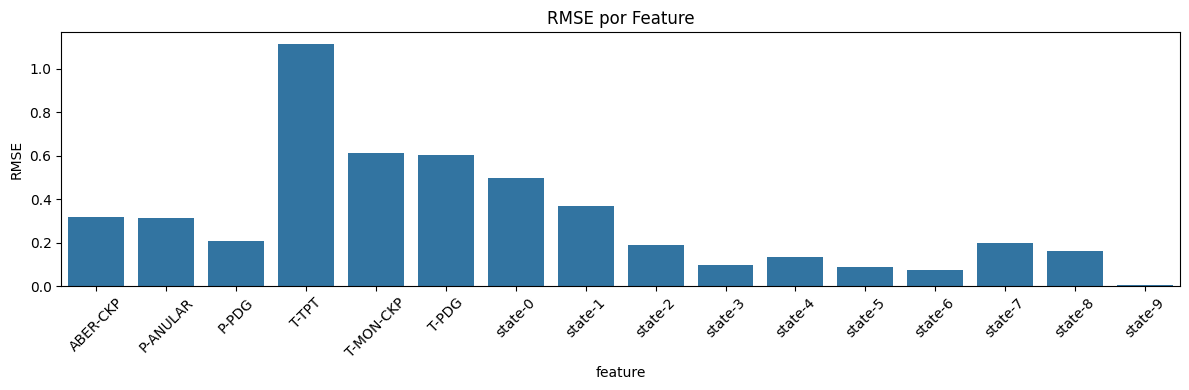

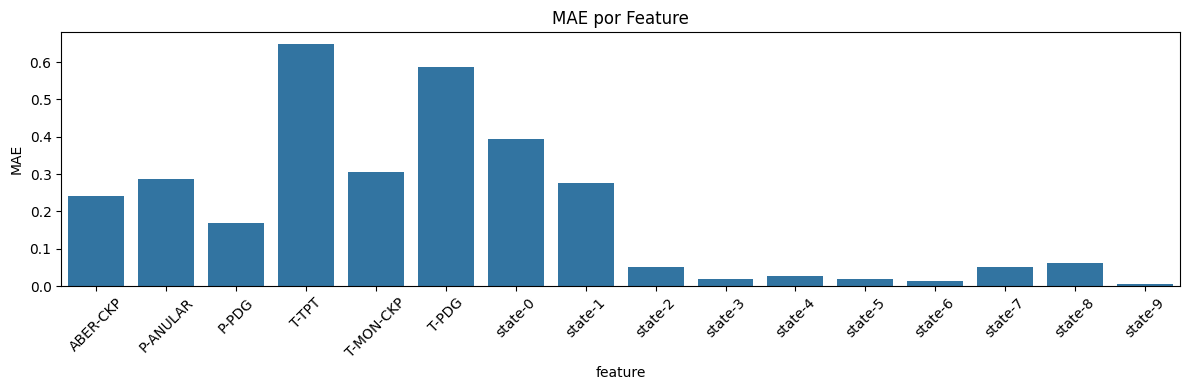

In [70]:
%matplotlib inline
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
metrics = ts_diffusion.evaluate_datasets(
    test_datasets=1,
    window_size=15,
    batch_size=1000,
    missing_frac=0.3,     # igual ao seu test_impute
    sampling_steps=100
)

# 2) Plota
ts_diffusion.plot_metrics_matplotlib(metrics)

In [ ]:
%matplotlib inline
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
metrics = ts_diffusion.evaluate_datasets(
    test_datasets=1,
    window_size=15,
    batch_size=1000,
    missing_frac=0.3,     # igual ao seu test_impute
    sampling_steps=300
)

# 2) Plota
ts_diffusion.plot_metrics_matplotlib(metrics)